# Analyzing the difference between geodesic and tangent PCA

In [1]:
import os
import sys
from pathlib import Path
sys.path.append(str(Path(os.getcwd()).parent.absolute()))

In [2]:
import numpy as np
from numpy.linalg import norm
import matplotlib.pyplot as plt

from pca.bures_wasserstein_principal_geodesic_analysis import BuresWassersteinPGA
from pca.bures_wasserstein_tangent_pca import BuresWassersteinTPCA
from tools.generate import generate_spd_matrices_on_intersecting_geodesics

INFO: Using numpy backend


We randomly generate two intersecting geodesics in the space of SPD matrices for the Bures-Wasserstein metric, and sample `n_times` points on these geodesics between `-time` and `time`. We then perform geodesic and tangent pca on these SPD matrices and compare the results in terms of costs (sum of squared residuals on each component). While in tangent PCA, the principal components intersect at the Fréchet mean by construction, this is no longer true for geodesic PCA. Therefore we also compare the intersection of the principal components for each method. We iterate this procedure `n_iter` times in order to get an overview of the different behaviors of the two methods.

In [3]:
dim = 2
time = 10.
n_times = 10
n_iter = 100

In [4]:
np.random.seed(1)

curvature = np.zeros(n_iter)
ratio_cost_1 = np.zeros(n_iter)
ratio_cost_2 = np.zeros(n_iter)
ratio_mean = np.zeros(n_iter)
diff_mean_middle = np.zeros(n_iter)

for i in range(n_iter):
    if i%10 == 0: print(i, end=" ")
    points_spd, mean, curv = generate_spd_matrices_on_intersecting_geodesics(dim=dim, n_times=n_times, time=time)

    res_tpca = BuresWassersteinTPCA.fit(points_spd)
    res_pga = BuresWassersteinPGA(dim=2).fit(points_spd)

    curvature[i] = curv
    ratio_cost_1[i] = (res_tpca['cost_1'] - res_pga['cost_1']) / res_tpca['cost_1']
    ratio_cost_2[i] = (res_tpca['cost_2'] - res_pga['cost_2']) / res_tpca['cost_2']
    ratio_mean[i] = norm(res_tpca['mean_spd'] - res_pga['mean_spd']) / norm(res_tpca['mean_spd'])
    diff_mean_middle[i] = norm(res_tpca['mean_spd'] - mean) / norm(mean)

0 10 20 30 40 50 60 70 80 90 

In [5]:
mask_1 = (np.abs(ratio_cost_1) < 0.01) * (np.abs(ratio_cost_2) < 0.01)                                    # no significant change
mask_2 = (ratio_cost_1 < -0.01) + (ratio_cost_2 < -0.01)                                                  # deterioration
mask_3 = (ratio_cost_1 > 0.01) * (ratio_cost_2 > -0.01) + (ratio_cost_1 > -0.01) * (ratio_cost_2 > 0.01)  # improvement
mask_4 = (ratio_cost_1 > 0.1) * (ratio_cost_2 > -0.01) + (ratio_cost_1 > -0.01) * (ratio_cost_2 > 0.1)    # important improvement

print(f'Less than 1% change in {np.sum(mask_1)} cases')
print(f'More than 1% deterioration in {np.sum(mask_2)} cases')
print(f'More than 1% improvement in {np.sum(mask_3)} cases')
print(f'More than 10% improvement in {np.sum(mask_4)} cases')

Less than 1% change in 64 cases
More than 1% deterioration in 1 cases
More than 1% improvement in 35 cases
More than 10% improvement in 19 cases


We see that except in a small minority of cases, geodesic PCA's performance is better or equivalent to tangent PCA. We also have some cases where the improvement is significant, i.e., larger than 10%, for at least one the the two costs. 

We expect the difference between geodesic and tangent PCA to be correlated to curvature in some way. Since the curvature of the Bures-Wasserstein metric is positive, the Fréchet mean of the SPD matrices aligned on the two intersecting geodesics is not necessarily equal to the intersection of the geodesics. Below, we plot the cost differences with respect to three different quantities:
- the curvature at the intersection of the geodesics
- the difference between the Fréchet mean and the intersection of the two geodesics
- the difference between the Fréchet mean and the geodesic PCA mean

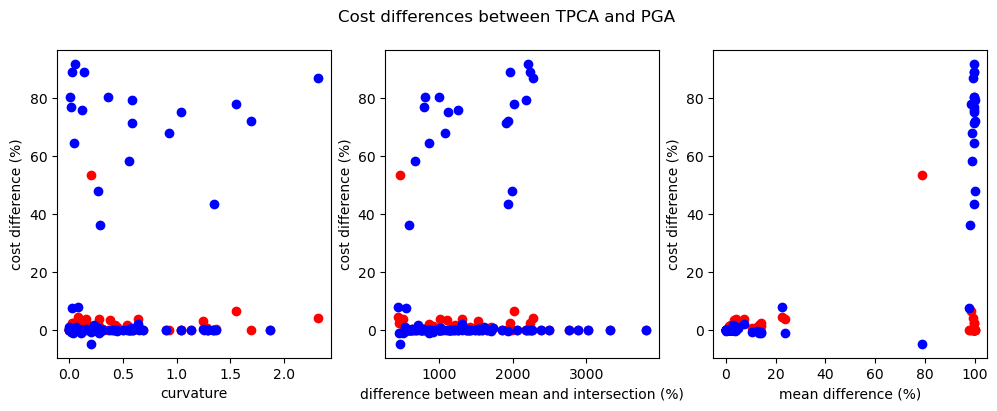

In [6]:
fig = plt.figure(figsize=(12, 4))
fig.add_subplot(131)
plt.plot(curvature, ratio_cost_1 * 100, 'or')
plt.plot(curvature, ratio_cost_2 * 100, 'ob')
plt.xlabel('curvature')
plt.ylabel('cost difference (%)')

fig.add_subplot(132)
plt.plot(diff_mean_middle * 100, ratio_cost_1 * 100, 'or')
plt.plot(diff_mean_middle * 100, ratio_cost_2 * 100, 'ob')
plt.xlabel('difference between mean and intersection (%)')
plt.ylabel('cost difference (%)')

fig.add_subplot(133)
plt.plot(ratio_mean * 100, ratio_cost_1 * 100, 'or')
plt.plot(ratio_mean * 100, ratio_cost_2 * 100, 'ob')
plt.xlabel('mean difference (%)')
plt.ylabel('cost difference (%)')
plt.suptitle('Cost differences between TPCA and PGA')
plt.show()

The first thing that we notice is that the important improvements of the cost of PGA w.r.t TPCA mostly happen for the second component. 

We see from the first plot that the performance differences between PGA and TPCA do not seem to be linked with the curvature at the intersection. This is probably because the effect of the curvature at the intersection is negligeable compared to the curvature along the entire geodesics, especially as `time` increases. 

There does not seem to be a correlation with the difference between the Fréchet mean and the intersection either. However we see from the third plot that the performance differences are highly correlated with the differences between the PGA and TPCA means. The cases where PGA performs much better than TPCA are those where the PGA-mean is very different from the TPCA-mean. It seems that the first components stay quite similar for the two methods, while the second components differ, since they do not intersect the first component at the same point. 